In [6]:
from sklearn.cluster import KMeans
from sklearn import metrics
from scipy.spatial.distance import cdist
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from sklearn import preprocessing

In [4]:
df = pd.read_csv(r"C:\Users\marie\rep_codes\udder_project\udder_processing\features_dict\gmfeature_table_cluster.csv")
df = df.dropna()
print(df.shape)
print(df.head())

(129, 44)
   cow  udder_vol    lf_vol    rf_vol    lb_vol    rb_vol  udder_sarea  \
0  627   6.742235  2.085106  2.320265  0.655287  0.907118  2202.840957   
1  723   5.866114  3.189081  1.988038  0.497105  0.565673  1557.547077   
2  729   7.537096  5.068295  4.355240  0.786221  0.891771  2106.038218   
3  736   8.529069  5.034365  1.684315  1.298735  0.676856  2190.923732   
4  764   6.316109  1.788540  2.241100  0.752663  0.685146  2106.038218   

      lf_sarea    rf_sarea    lb_sarea  ...    lb_exc     rb_peri  \
0   676.526869  710.606157  388.758950  ...  0.596490  445.643145   
1   620.012292  569.962040  259.224542  ...  0.833681  451.755880   
2   704.983437  998.056447  255.710493  ...  0.667343  461.791414   
3  1036.329523  415.856293  525.530135  ...  0.401467  506.303607   
4   825.074567  901.399146  567.414139  ...  0.628288  470.700577   

        rb_area   rb_circ    rb_exc     lf_len     rf_len     lb_len  \
0  10070.258065  0.748797  0.541033  37.991288  41.337529 

In [11]:
X = df.iloc[:, 1:]
scaler = preprocessing.StandardScaler().fit(X)
X_scaled = scaler.transform(X)

In [13]:
distortions = []
inertias = []
mapping1 = {}
mapping2 = {}
K = range(1, 10)

for k in K:
    kmeanModel = KMeans(n_clusters=k, random_state=42).fit(X)
    
    distortions.append(sum(np.min(cdist(X, kmeanModel.cluster_centers_, 'euclidean'), axis=1)**2) / X.shape[0])
    
    inertias.append(kmeanModel.inertia_)
    
    mapping1[k] = distortions[-1]
    mapping2[k] = inertias[-1]

C:\Users\marie\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\marie\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\marie\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\marie\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Wi

Distortion values:
1 : 264281733.829547
2 : 132789537.84572043
3 : 93523705.27149774
4 : 79003716.30709451
5 : 67780412.33556536
6 : 59427778.04374689
7 : 53614006.3850329
8 : 48587689.14089418
9 : 44924485.18669688


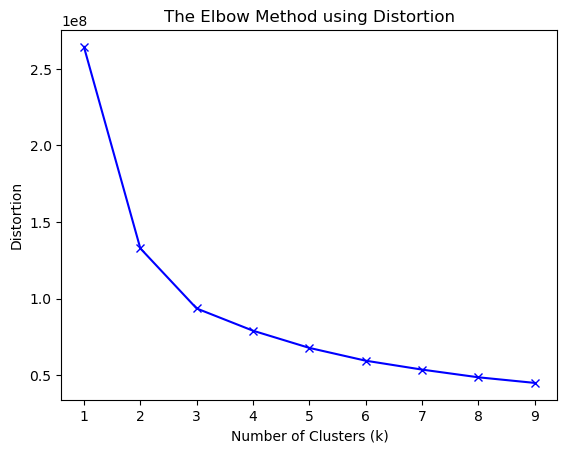

In [15]:
print("Distortion values:")
for key, val in mapping1.items():
    print(f'{key} : {val}')

plt.plot(K, distortions, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Distortion')
plt.title('The Elbow Method using Distortion')
plt.show()

In [21]:
kmeans = KMeans(n_clusters=3, random_state=5, n_init="auto").fit(X)
df["cluster"] = kmeans.labels_

C:\Users\marie\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


<Axes: xlabel='cluster', ylabel='udder_vol'>

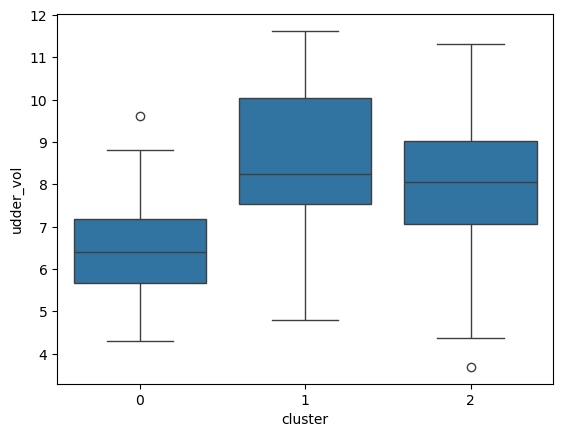

In [24]:
import seaborn as sns
sns.boxplot(x = df.cluster, y = df.udder_vol)

In [26]:
# Train a classifier
# https://towardsdatascience.com/interpretable-k-means-clusters-feature-importances-7e516eeb8d3c/
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(random_state=1)
clf.fit(X.values,df["cluster"].values)

# Index sort the most important features
sorted_feature_weight_idxes = np.argsort(clf.feature_importances_)[::-1] # Reverse sort

# Get the most important features names and weights
most_important_features = np.take_along_axis(
    np.array(df.iloc[:, :].columns.tolist()), 
    sorted_feature_weight_idxes, axis=0)
most_important_weights = np.take_along_axis(
    np.array(clf.feature_importances_), 
    sorted_feature_weight_idxes, axis=0)

# Show
list(zip(most_important_features, most_important_weights))

[('udder_peri', 0.20377953054367695),
 ('left_gd', 0.145378380886743),
 ('udder_exc', 0.06622609812408027),
 ('lf_peri', 0.06450011262472449),
 ('udder_sarea', 0.05064079034954347),
 ('rb_vol', 0.037182555486917325),
 ('lf_area', 0.027129123300754742),
 ('lf_exc', 0.02622476241094768),
 ('udder_vol', 0.024664485208216416),
 ('right_gd', 0.02461863491664616),
 ('left_eu', 0.022667698867601702),
 ('cow', 0.02032545437364624),
 ('back_eu', 0.017541468948171827),
 ('rf_peri', 0.0159598097696301),
 ('lf_vol', 0.015088433335907757),
 ('right_eu', 0.013758646792356926),
 ('rf_exc', 0.013620423015039603),
 ('lb_sarea', 0.013152071953494356),
 ('lb_peri', 0.011846548298670852),
 ('back_gd', 0.011390644891000966),
 ('lb_area', 0.011168602018197298),
 ('udder_area', 0.010152528872899948),
 ('rf_sarea', 0.009735090866810504),
 ('lb_len', 0.009641575901553234),
 ('rf_vol', 0.009516744415102231),
 ('lf_circ', 0.009505470121270787),
 ('lb_exc', 0.009471455542305291),
 ('udder_circ', 0.009442958120059